Base Model

In [21]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
file_path = "/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv"
df = pd.read_csv(file_path)

TARGET = "Gallstone Status"
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Distribusi kelas:")
print(y.value_counts())


Distribusi kelas:
Gallstone Status
0    452
1    161
Name: count, dtype: int64


In [23]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)


In [24]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


In [25]:
n_features = X_train.shape[1]

X_train_lstm = X_train.reshape((-1, 1, n_features))
X_val_lstm   = X_val.reshape((-1, 1, n_features))
X_test_lstm  = X_test.reshape((-1, 1, n_features))


In [26]:
def build_lstm():
    model = Sequential()
    model.add(LSTM(
        units=64,
        input_shape=(1, n_features),
        return_sequences=False
    ))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation="relu"))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [27]:
model = build_lstm()
model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 64)             │        24,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,433 (103.25 KB)

 Trainable params: 26,433 (103.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.5791 - loss: 0.6794 - val_accuracy: 0.6911 - val_loss: 0.6606
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7545 - loss: 0.6250 - val_accuracy: 0.7561 - val_loss: 0.6182
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7480 - loss: 0.5810 - val_accuracy: 0.7967 - val_loss: 0.5777
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7671 - loss: 0.5407 - val_accuracy: 0.7886 - val_loss: 0.5274
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8025 - loss: 0.4901 - val_accuracy: 0.7967 - val_loss: 0.4807
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8175 - loss: 0.4487 - val_accuracy: 0.7724 - val_loss: 0.4586
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8335 - loss: 0.4245 - val_accuracy: 0.7724 - val_loss: 0.4310
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8405 - loss: 0.3916 - val_accuracy: 0.7805 - v

In [28]:
y_pred_proba = model.predict(X_test_lstm).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_proba))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Accuracy : 0.6910569105691057
Precision: 0.4375
Recall   : 0.65625
F1-score : 0.525
ROC-AUC  : 0.7857142857142857


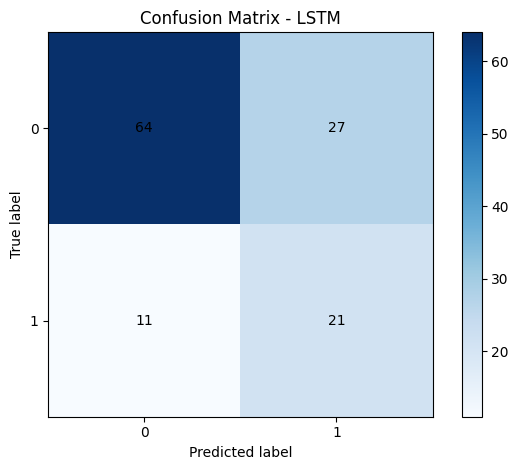

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - LSTM")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


AUC (LSTM - Test Set): 0.7837


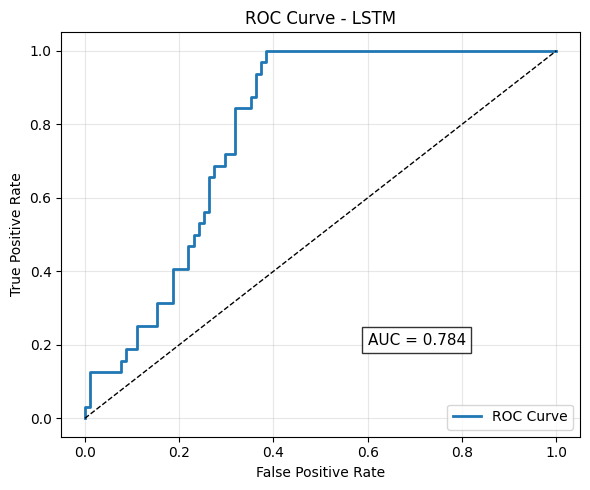

In [48]:
# Hitung ROC & AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_value = roc_auc_score(y_test, y_pred_proba)

# Tampilkan nilai AUC di console
print(f"AUC (LSTM - Test Set): {auc_value:.4f}")

# Plot ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label="ROC Curve")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)

# Annotasi nilai AUC di plot
plt.text(
    0.6, 0.2,
    f"AUC = {auc_value:.3f}",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


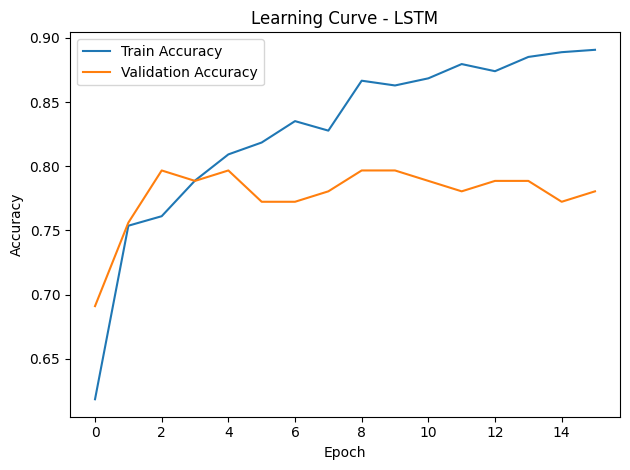

In [31]:
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curve - LSTM")
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
output_dir = "/content/drive/MyDrive/Tesis/Fix FE HO/LSTM/Base Model/"
os.makedirs(output_dir, exist_ok=True)

model.save(output_dir + "lstm_model.h5")
joblib.dump(scaler, output_dir + "scaler.pkl")

print("Model & scaler berhasil disimpan.")


Model & scaler berhasil disimpan.


Parameter Tunning

In [33]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
file_path = "/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv"
df = pd.read_csv(file_path)

TARGET = "Gallstone Status"
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Distribusi kelas:")
print(y.value_counts())


Distribusi kelas:
Gallstone Status
0    452
1    161
Name: count, dtype: int64


In [35]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)


In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


In [37]:
n_features = X_train.shape[1]

X_train_lstm = X_train.reshape((-1, 1, n_features))
X_val_lstm   = X_val.reshape((-1, 1, n_features))
X_test_lstm  = X_test.reshape((-1, 1, n_features))


In [38]:
def build_lstm(units, dense_units, dropout, lr):
    model = Sequential()
    model.add(LSTM(
        units=units,
        input_shape=(1, n_features),
        return_sequences=False
    ))
    model.add(Dropout(dropout))
    model.add(Dense(dense_units, activation="relu"))
    model.add(Dropout(dropout))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [39]:
param_space = {
    "units": [32, 64, 128],
    "dense_units": [16, 32, 64],
    "dropout": [0.2, 0.3, 0.5],
    "lr": [1e-4, 5e-4, 1e-3],
    "batch_size": [16, 32, 64],
    "epochs": [50, 75]
}

N_ITER = 20  # jumlah random trial


In [40]:
best_f1 = 0
best_config = None
best_model = None
history_best = None

for i in range(N_ITER):
    print(f"\n=== Trial {i+1}/{N_ITER} ===")

    config = {k: random.choice(v) for k, v in param_space.items()}
    print("Config:", config)

    model = build_lstm(
        units=config["units"],
        dense_units=config["dense_units"],
        dropout=config["dropout"],
        lr=config["lr"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_lstm, y_train,
        validation_data=(X_val_lstm, y_val),
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    y_val_pred = (model.predict(X_val_lstm) >= 0.5).astype(int)
    f1 = f1_score(y_val, y_val_pred)

    print("Validation F1:", f1)

    if f1 > best_f1:
        best_f1 = f1
        best_config = config
        best_model = model
        history_best = history



=== Trial 1/20 ===
Config: {'units': 64, 'dense_units': 32, 'dropout': 0.3, 'lr': 0.0001, 'batch_size': 32, 'epochs': 50}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Validation F1: 0.6588235294117647

=== Trial 2/20 ===
Config: {'units': 128, 'dense_units': 16, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 16, 'epochs': 50}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Validation F1: 0.6582278481012658

=== Trial 3/20 ===
Config: {'units': 128, 'dense_units': 64, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 16, 'epochs': 75}


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Validation F1: 0.6666666666666666

=== Trial 19/20 ===
Config: {'units': 32, 'dense_units': 16, 'dropout': 0.3, 'lr': 0.0001, 'batch_size': 64, 'epochs': 50}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Validation F1: 0.6

=== Trial 20/20 ===
Config: {'units': 128, 'dense_units': 64, 'dropout': 0.5, 'lr': 0.001, 'batch_size': 16, 'epochs': 50}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Validation F1: 0.6216216216216216


In [41]:
print("\n=== BEST RESULT ===")
print("Best Validation F1:", best_f1)
print("Best Hyperparameters:")
for k, v in best_config.items():
    print(f"{k}: {v}")



=== BEST RESULT ===
Best Validation F1: 0.675
Best Hyperparameters:
units: 128
dense_units: 64
dropout: 0.3
lr: 0.001
batch_size: 16
epochs: 75


In [42]:
y_pred_proba = best_model.predict(X_test_lstm).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

print("\n=== TEST SET PERFORMANCE ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_proba))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

=== TEST SET PERFORMANCE ===
Accuracy : 0.7073170731707317
Precision: 0.46
Recall   : 0.71875
F1-score : 0.5609756097560976
ROC-AUC  : 0.7836538461538463


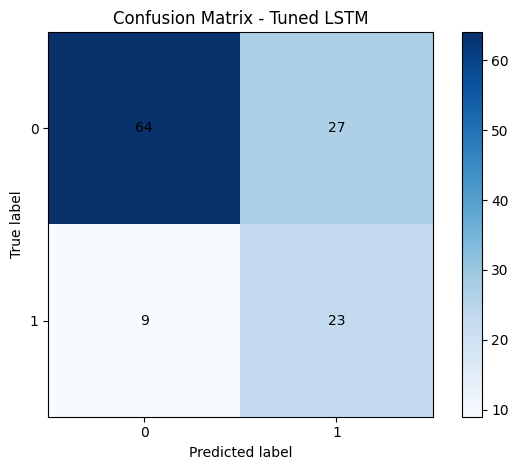

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - Tuned LSTM")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


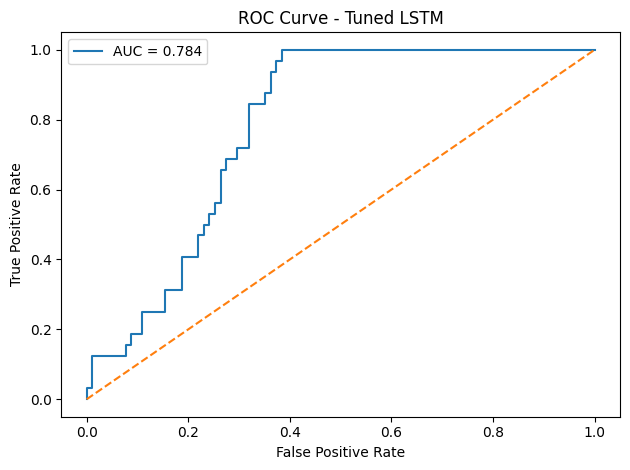

In [47]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_proba):.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned LSTM")
plt.legend()
plt.tight_layout()
plt.show()


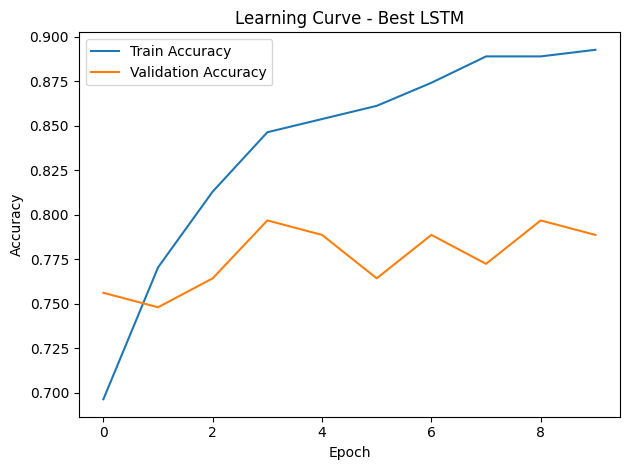

In [45]:
plt.figure()
plt.plot(history_best.history["accuracy"], label="Train Accuracy")
plt.plot(history_best.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Best LSTM")
plt.legend()
plt.tight_layout()
plt.show()


In [46]:
output_dir = "/content/drive/MyDrive/Tesis/Fix FE HO/LSTM/Tuned Model/"
os.makedirs(output_dir, exist_ok=True)

best_model.save(output_dir + "best_lstm_model.h5")
joblib.dump(scaler, output_dir + "scaler.pkl")

with open(output_dir + "best_lstm_params.json", "w") as f:
    json.dump(best_config, f, indent=4)

print("Model, scaler, dan parameter berhasil disimpan.")


Model, scaler, dan parameter berhasil disimpan.
